In [2]:
from google.colab import files

uploaded = files.upload()

Saving Quality of Service 5G.csv to Quality of Service 5G.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("Quality of Service 5G.csv")


In [5]:
df.head()

,Timestamp,User_ID,Application_Type,Signal_Strength,Latency,Required_Bandwidth,Allocated_Bandwidth,Resource_Allocation
0,9/3/2023 10:00,User_1,Video_Call,-75 dBm,30 ms,10 Mbps,15 Mbps,70%
1,9/3/2023 10:00,User_2,Voice_Call,-80 dBm,20 ms,100 Kbps,120 Kbps,80%
2,9/3/2023 10:00,User_3,Streaming,-85 dBm,40 ms,5 Mbps,6 Mbps,75%
3,9/3/2023 10:00,User_4,Emergency_Service,-70 dBm,10 ms,1 Mbps,1.5 Mbps,90%
4,9/3/2023 10:00,User_5,Online_Gaming,-78 dBm,25 ms,2 Mbps,3 Mbps,85%


In [6]:
df.shape

(400, 8)

In [7]:
df.columns

Index(['Timestamp', 'User_ID', 'Application_Type', 'Signal_Strength',
       'Latency', 'Required_Bandwidth', 'Allocated_Bandwidth',
       'Resource_Allocation'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Timestamp            400 non-null    object
 1   User_ID              400 non-null    object
 2   Application_Type     400 non-null    object
 3   Signal_Strength      400 non-null    object
 4   Latency              400 non-null    object
 5   Required_Bandwidth   400 non-null    object
 6   Allocated_Bandwidth  400 non-null    object
 7   Resource_Allocation  400 non-null    object
dtypes: object(8)
memory usage: 25.1+ KB


In [9]:
df.describe()

,Timestamp,User_ID,Application_Type,Signal_Strength,Latency,Required_Bandwidth,Allocated_Bandwidth,Resource_Allocation
count,400,400,400,400,400,400,400,400
unique,7,400,11,84,87,188,194,9
top,9/3/2023 10:01,User_384,Video_Call,-85 dBm,5 ms,0.1 Mbps,0.1 Mbps,70%
freq,60,1,58,9,35,16,16,148


In [10]:
df.isnull().sum()

,0
Timestamp,0
User_ID,0
Application_Type,0
Signal_Strength,0
Latency,0
Required_Bandwidth,0
Allocated_Bandwidth,0
Resource_Allocation,0


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.dtypes

,0
Timestamp,object
User_ID,object
Application_Type,object
Signal_Strength,object
Latency,object
Required_Bandwidth,object
Allocated_Bandwidth,object
Resource_Allocation,object


In [13]:
df.nunique()

,0
Timestamp,7
User_ID,400
Application_Type,11
Signal_Strength,84
Latency,87
Required_Bandwidth,188
Allocated_Bandwidth,194
Resource_Allocation,9


In [14]:
df.sample(5)

,Timestamp,User_ID,Application_Type,Signal_Strength,Latency,Required_Bandwidth,Allocated_Bandwidth,Resource_Allocation
104,9/3/2023 10:01,User_105,Streaming,-77 dBm,32 ms,4.5 Mbps,5.1 Mbps,85%
286,9/3/2023 10:04,User_287,Emergency_Service,-48 dBm,5 ms,0.5 Mbps,0.5 Mbps,70%
247,9/3/2023 10:04,User_248,Web_Browsing,-103 dBm,13 ms,0.3 Mbps,0.3 Mbps,70%
331,9/3/2023 10:05,User_332,Streaming,-102 dBm,53 ms,2.1 Mbps,2.6 Mbps,85%
12,9/3/2023 10:00,User_13,Web_Browsing,-87 dBm,28 ms,1.2 Mbps,1.2 Mbps,65%


In [15]:
df["Resource_Allocation"].value_counts()

,count
Resource_Allocation,
70%,148
75%,58
85%,48
90%,47
60%,47
80%,46
65%,4
50%,1
55%,1


In [16]:
df.corr(numeric_only=True)

""


In [17]:
df.dtypes

,0
Timestamp,object
User_ID,object
Application_Type,object
Signal_Strength,object
Latency,object
Required_Bandwidth,object
Allocated_Bandwidth,object
Resource_Allocation,object


In [18]:
numeric_df = df.select_dtypes(include='number')
numeric_df.head()

""
0
1
2
3
4


In [19]:


df["Signal_Strength"] = df["Signal_Strength"].str.replace(" dBm", "").astype(int)

df["Latency"] = df["Latency"].str.replace(" ms", "").astype(int)

df["Required_Bandwidth"] = (
    df["Required_Bandwidth"]
      .str.replace(" Mbps", "")
      .str.replace(" Kbps", "")
      .astype(float)
)

df["Allocated_Bandwidth"] = (
    df["Allocated_Bandwidth"]
      .str.replace(" Mbps", "")
      .str.replace(" Kbps", "")
      .astype(float)
)

df["Resource_Allocation"] = (
    df["Resource_Allocation"]
      .str.replace("%", "")
      .astype(int)
)

In [20]:
df.dtypes

,0
Timestamp,object
User_ID,object
Application_Type,object
Signal_Strength,int64
Latency,int64
Required_Bandwidth,float64
Allocated_Bandwidth,float64
Resource_Allocation,int64


In [21]:
numeric_df = df.select_dtypes(include="number")
numeric_df.corr()

,Signal_Strength,Latency,Required_Bandwidth,Allocated_Bandwidth,Resource_Allocation
Signal_Strength,1.000000,-0.392676,-0.380059,-0.376591,0.303580
Latency,-0.392676,1.000000,0.335820,0.332892,-0.137848
Required_Bandwidth,-0.380059,0.335820,1.000000,0.999035,-0.495025
Allocated_Bandwidth,-0.376591,0.332892,0.999035,1.000000,-0.468691
Resource_Allocation,0.303580,-0.137848,-0.495025,-0.468691,1.000000


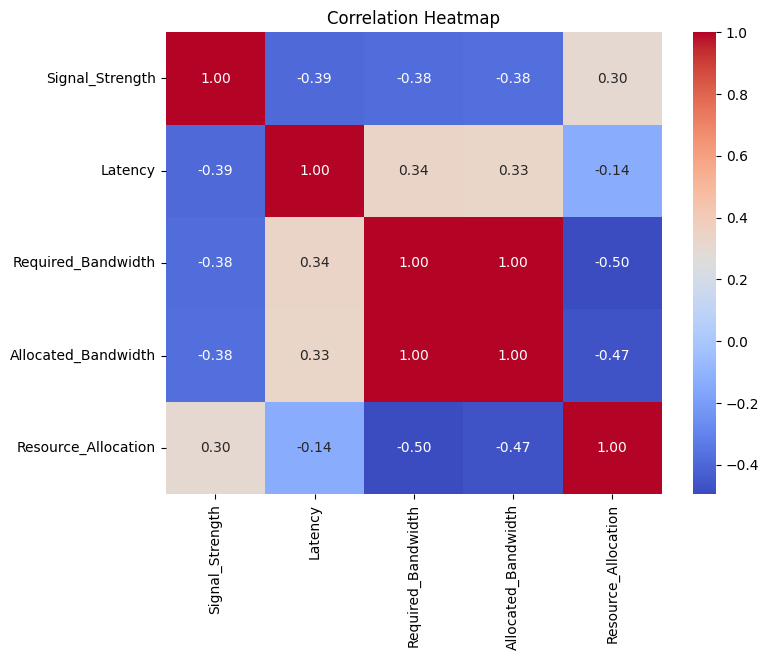

In [22]:
plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

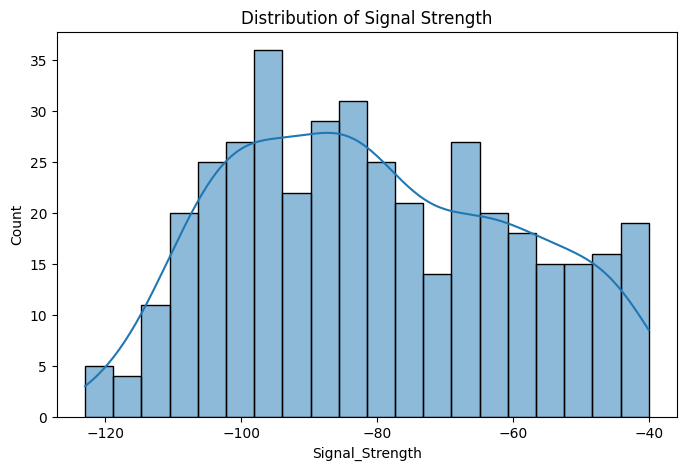

In [23]:
plt.figure(figsize=(8,5))
sns.histplot(df["Signal_Strength"], bins=20, kde=True)
plt.title("Distribution of Signal Strength")
plt.show()

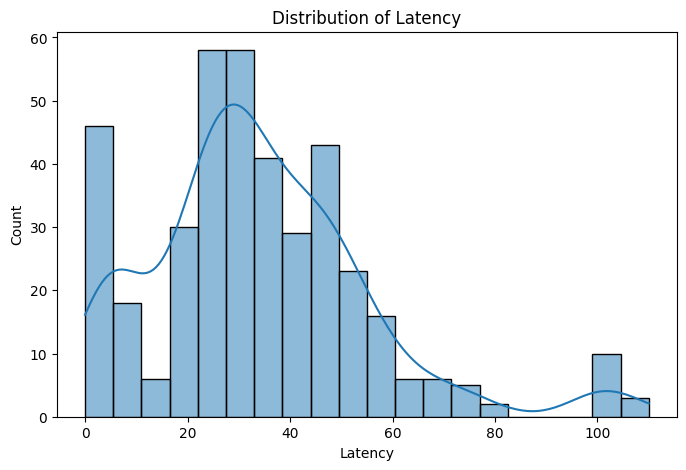

In [24]:
plt.figure(figsize=(8,5))
sns.histplot(df["Latency"], bins=20, kde=True)
plt.title("Distribution of Latency")
plt.show()

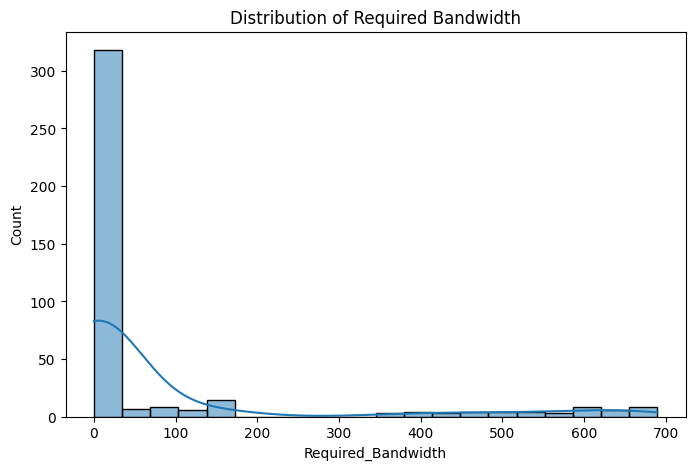

In [25]:
plt.figure(figsize=(8,5))
sns.histplot(df["Required_Bandwidth"], bins=20, kde=True)
plt.title("Distribution of Required Bandwidth")
plt.show()

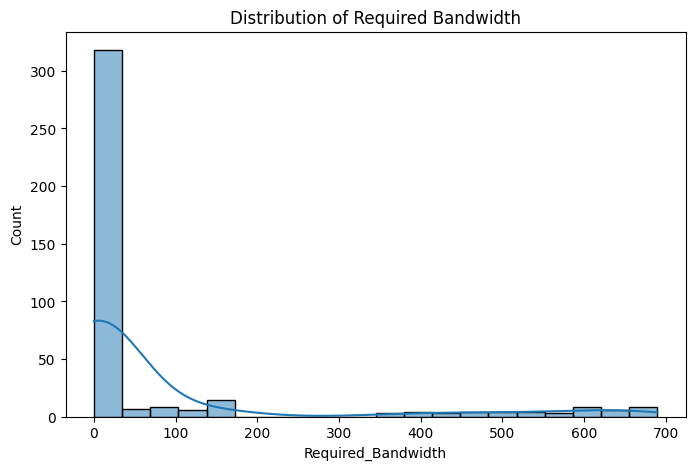

In [26]:
plt.figure(figsize=(8,5))
sns.histplot(df["Required_Bandwidth"], bins=20, kde=True)
plt.title("Distribution of Required Bandwidth")
plt.show()

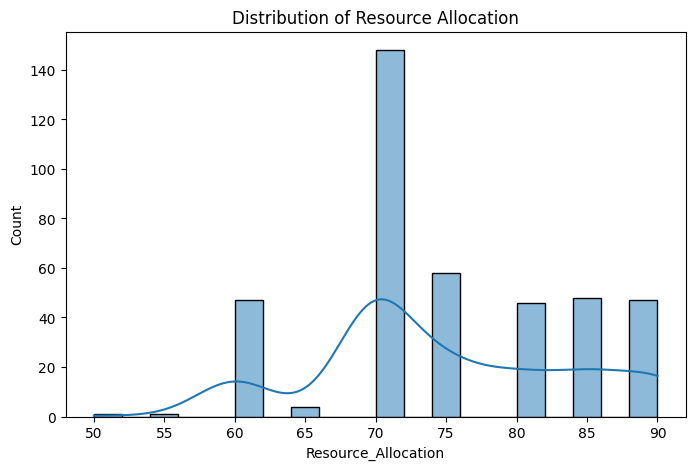

In [27]:
plt.figure(figsize=(8,5))
sns.histplot(df["Resource_Allocation"], bins=20, kde=True)
plt.title("Distribution of Resource Allocation")
plt.show()

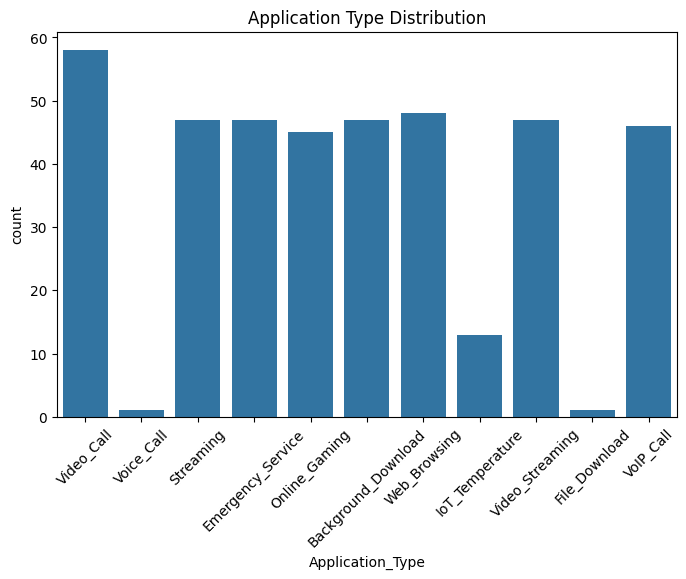

In [30]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Application_Type")
plt.title("Application Type Distribution")
plt.xticks(rotation=45)
plt.show()

In [27]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Application_Type", y="Signal_Strength")
plt.xticks(rotation=45)
plt.title("Signal Strength by Application Type")
plt.show()

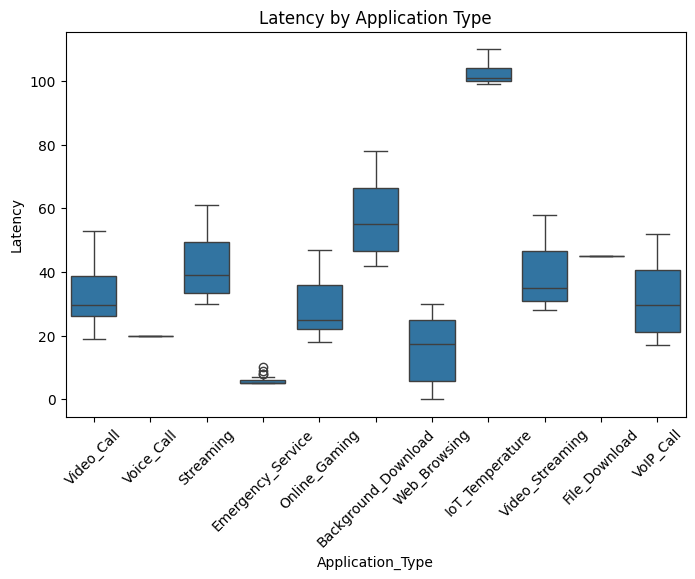

In [28]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Application_Type", y="Latency")
plt.xticks(rotation=45)
plt.title("Latency by Application Type")
plt.show()

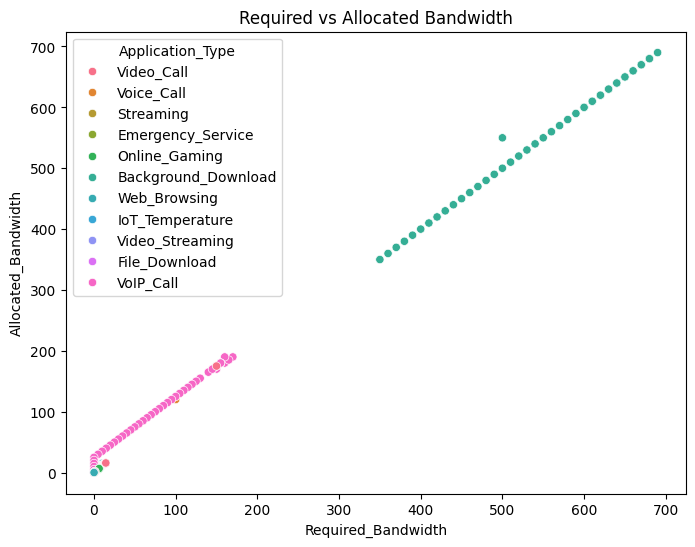

In [29]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="Required_Bandwidth",
    y="Allocated_Bandwidth",
    hue="Application_Type"
)
plt.title("Required vs Allocated Bandwidth")
plt.show()

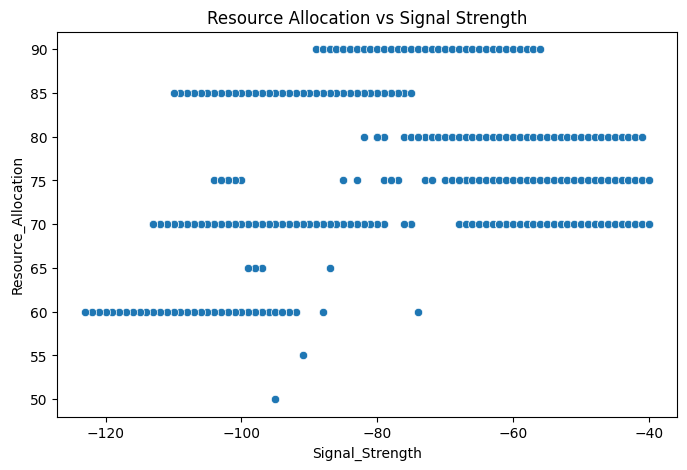

In [31]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x="Signal_Strength",
    y="Resource_Allocation"
)
plt.title("Resource Allocation vs Signal Strength")
plt.show()

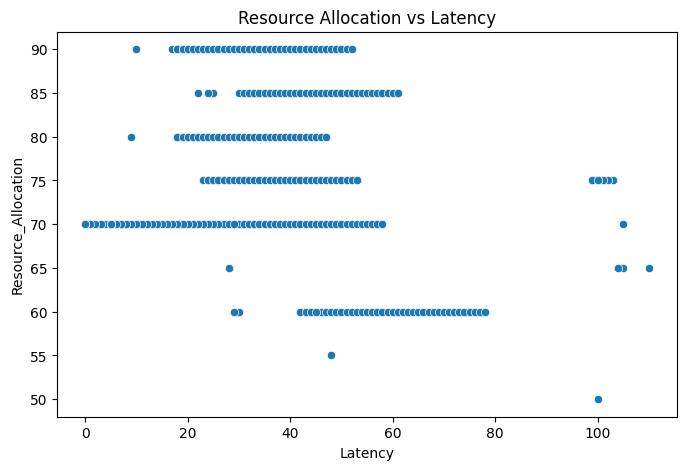

In [32]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x="Latency",
    y="Resource_Allocation"
)
plt.title("Resource Allocation vs Latency")
plt.show()

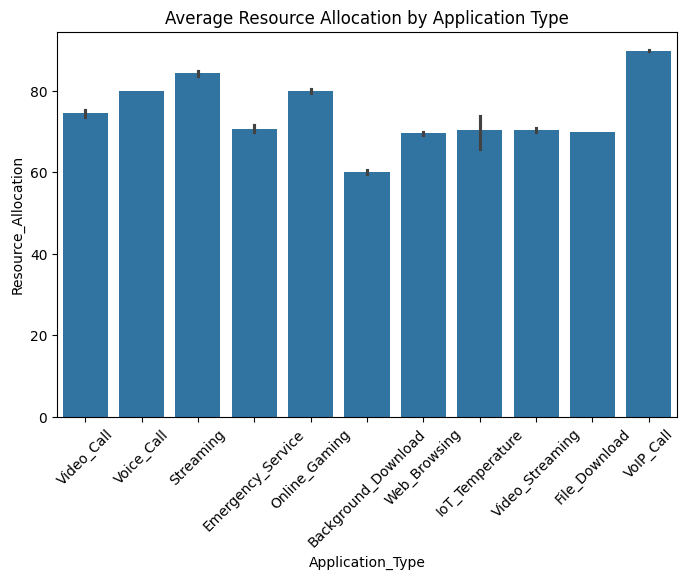

In [33]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=df,
    x="Application_Type",
    y="Resource_Allocation"
)
plt.xticks(rotation=45)
plt.title("Average Resource Allocation by Application Type")
plt.show()

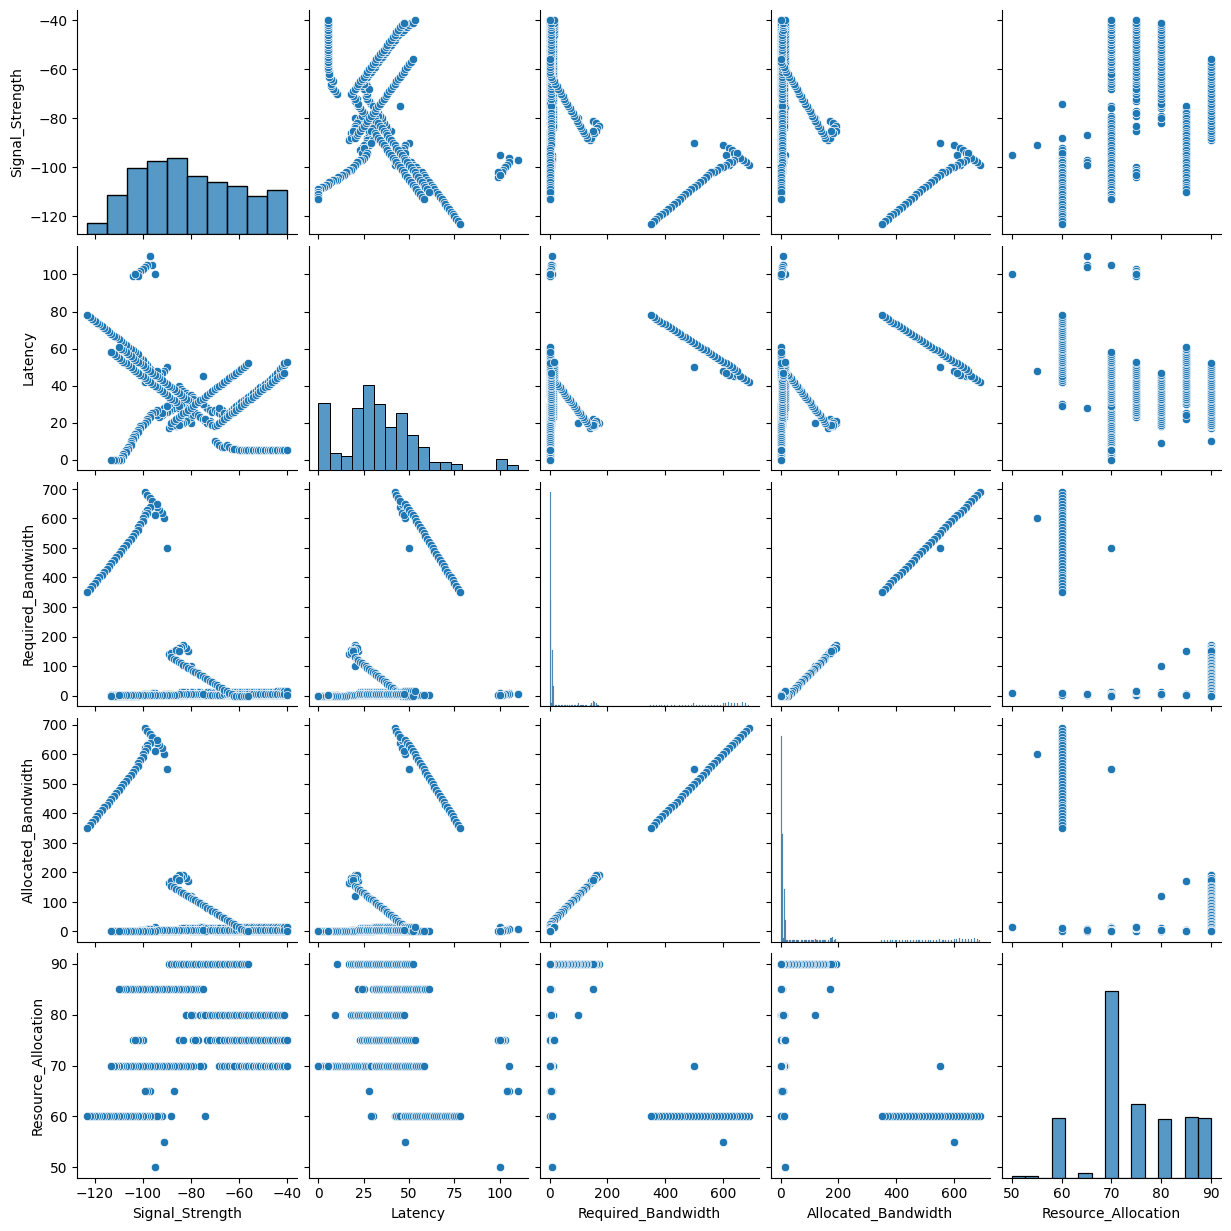

In [34]:
sns.pairplot(
    df[[
        "Signal_Strength",
        "Latency",
        "Required_Bandwidth",
        "Allocated_Bandwidth",
        "Resource_Allocation"
    ]]
)
plt.show()

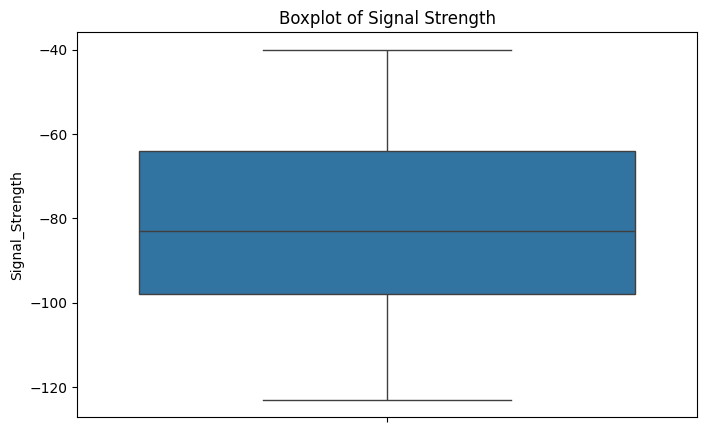

In [35]:
plt.figure(figsize=(8,5))
sns.boxplot(y=df["Signal_Strength"])
plt.title("Boxplot of Signal Strength")
plt.show()

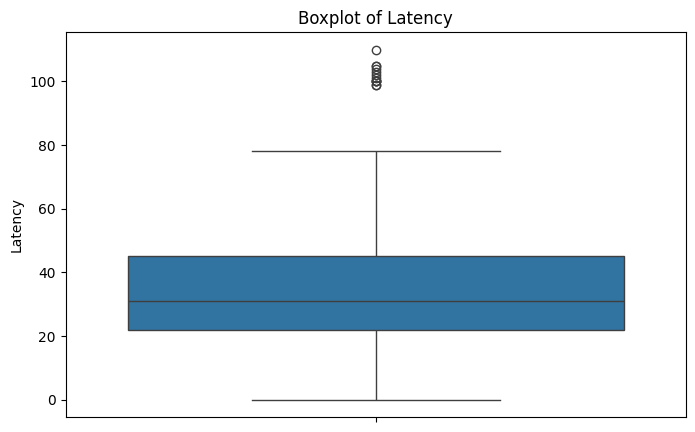

In [36]:
plt.figure(figsize=(8,5))
sns.boxplot(y=df["Latency"])
plt.title("Boxplot of Latency")
plt.show()

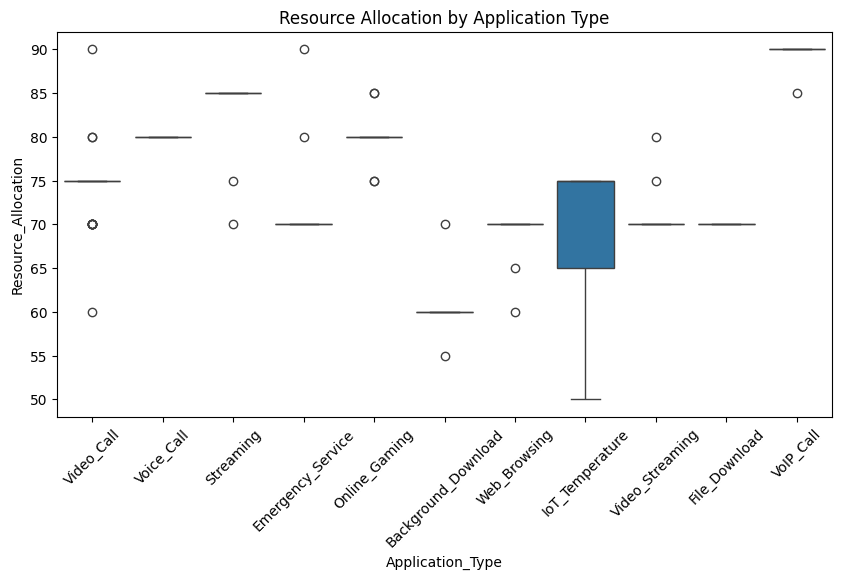

In [37]:
plt.figure(figsize=(10,5))
sns.boxplot(
    data=df,
    x="Application_Type",
    y="Resource_Allocation"
)
plt.xticks(rotation=45)
plt.title("Resource Allocation by Application Type")
plt.show()

In [38]:
df.groupby("Application_Type")[
    [
        "Signal_Strength",
        "Latency",
        "Required_Bandwidth",
        "Allocated_Bandwidth",
        "Resource_Allocation"
    ]
].mean()

,Signal_Strength,Latency,Required_Bandwidth,Allocated_Bandwidth,Resource_Allocation
Application_Type,,,,,
Background_Download,-104.063830,56.978723,547.872340,548.936170,60.106383
Emergency_Service,-53.829787,5.574468,0.678723,0.744681,70.638298
File_Download,-75.000000,45.000000,2.000000,2.000000,70.000000
IoT_Temperature,-100.230769,102.153846,3.846154,5.153846,70.384615
Online_Gaming,-62.155556,29.111111,4.140000,4.455556,80.000000
Streaming,-89.617021,41.851064,3.353191,3.893617,84.468085
Video_Call,-62.396552,32.879310,14.398276,16.298276,74.482759
Video_Streaming,-93.936170,38.851064,2.938298,3.314894,70.319149
VoIP_Call,-75.782609,31.304348,81.630435,104.130435,89.891304


DATA PREPROCESSING

In [39]:
X = df.drop("Resource_Allocation", axis=1)
y = df["Resource_Allocation"]

In [40]:
X.head()

,Timestamp,User_ID,Application_Type,Signal_Strength,Latency,Required_Bandwidth,Allocated_Bandwidth
0,9/3/2023 10:00,User_1,Video_Call,-75,30,10.0,15.0
1,9/3/2023 10:00,User_2,Voice_Call,-80,20,100.0,120.0
2,9/3/2023 10:00,User_3,Streaming,-85,40,5.0,6.0
3,9/3/2023 10:00,User_4,Emergency_Service,-70,10,1.0,1.5
4,9/3/2023 10:00,User_5,Online_Gaming,-78,25,2.0,3.0


In [41]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

X["Application_Type"] = le.fit_transform(X["Application_Type"])

In [42]:
X.head()

,Timestamp,User_ID,Application_Type,Signal_Strength,Latency,Required_Bandwidth,Allocated_Bandwidth
0,9/3/2023 10:00,User_1,6,-75,30,10.0,15.0
1,9/3/2023 10:00,User_2,9,-80,20,100.0,120.0
2,9/3/2023 10:00,User_3,5,-85,40,5.0,6.0
3,9/3/2023 10:00,User_4,1,-70,10,1.0,1.5
4,9/3/2023 10:00,User_5,4,-78,25,2.0,3.0


MACHINE LEARNING

In [47]:
X = X.drop("Timestamp", axis=1)

In [48]:
X.dtypes

,0
User_ID,object
Application_Type,int64
Signal_Strength,int64
Latency,int64
Required_Bandwidth,float64
Allocated_Bandwidth,float64


In [50]:
X = X.drop("User_ID", axis=1)

In [51]:
X.dtypes

,0
Application_Type,int64
Signal_Strength,int64
Latency,int64
Required_Bandwidth,float64
Allocated_Bandwidth,float64


In [52]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [53]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (320, 5)
Testing data: (80, 5)


In [54]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [55]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [56]:
y_pred = model.predict(X_test)

In [57]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 0.9131249999999996


In [58]:
from sklearn.metrics import root_mean_squared_error

rmse = root_mean_squared_error(y_test, y_pred)
print("RMSE:", rmse)

RMSE: 2.824264284729742


In [59]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)

R² Score: 0.9089663412241986


In [60]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

print(importance)

               Feature  Importance
0     Application_Type    0.407171
4  Allocated_Bandwidth    0.369875
3   Required_Bandwidth    0.159258
1      Signal_Strength    0.040084
2              Latency    0.023612


In [61]:
client1 = df.sample(frac=0.33, random_state=42)
remaining = df.drop(client1.index)

client2 = remaining.sample(frac=0.5, random_state=42)
client3 = remaining.drop(client2.index)

print(len(client1), len(client2), len(client3))

132 134 134


In [62]:
print(client1.head())
print(client2.head())
print(client3.head())

          Timestamp   User_ID     Application_Type  Signal_Strength  Latency  \
209  9/3/2023 10:03  User_210            VoIP_Call              -79       29   
280  9/3/2023 10:04  User_281  Background_Download             -109       64   
33   9/3/2023 10:00   User_34            VoIP_Call              -83       20   
210  9/3/2023 10:03  User_211        Online_Gaming              -64       24   
93   9/3/2023 10:01   User_94            VoIP_Call              -89       17   

     Required_Bandwidth  Allocated_Bandwidth  Resource_Allocation  
209                85.0                110.0                   90  
280               490.0                490.0                   60  
33                170.0                190.0                   90  
210                 4.0                  4.3                   80  
93                140.0                165.0                   90  
          Timestamp   User_ID Application_Type  Signal_Strength  Latency  \
183  9/3/2023 10:03  User_184     W

In [63]:
from sklearn.preprocessing import StandardScaler

def prepare_client_data(client_df):
    X = client_df.drop(["Resource_Allocation", "Timestamp", "User_ID"], axis=1)
    y = client_df["Resource_Allocation"]

    X["Application_Type"] = LabelEncoder().fit_transform(X["Application_Type"])

    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    return X, y

In [64]:
X1, y1 = prepare_client_data(client1)

In [65]:
from sklearn.ensemble import RandomForestRegressor

client1_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

client1_model.fit(X1, y1)

RandomForestRegressor(random_state=42)

In [66]:
X2, y2 = prepare_client_data(client2)

client2_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

client2_model.fit(X2, y2)

RandomForestRegressor(random_state=42)

In [67]:
X3, y3 = prepare_client_data(client3)

client3_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

client3_model.fit(X3, y3)

RandomForestRegressor(random_state=42)

In [68]:
print("Client 1 Trees:", len(client1_model.estimators_))
print("Client 2 Trees:", len(client2_model.estimators_))
print("Client 3 Trees:", len(client3_model.estimators_))

Client 1 Trees: 100
Client 2 Trees: 100
Client 3 Trees: 100


In [69]:
X_global = df.drop(["User_ID", "Timestamp", "Resource_Allocation"], axis=1)

X_global["Application_Type"] = LabelEncoder().fit_transform(X_global["Application_Type"])

X_global = scaler.fit_transform(X_global)

In [70]:
pred1 = client1_model.predict(X_global)
pred2 = client2_model.predict(X_global)
pred3 = client3_model.predict(X_global)

In [71]:
global_prediction = (pred1 + pred2 + pred3) / 3

In [72]:
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

mae = mean_absolute_error(df["Resource_Allocation"], global_prediction)
rmse = np.sqrt(np.mean((df["Resource_Allocation"] - global_prediction) ** 2))
r2 = r2_score(df["Resource_Allocation"], global_prediction)

print("Global MAE:", mae)
print("Global RMSE:", rmse)
print("Global R²:", r2)

Global MAE: 2.3351249999999997
Global RMSE: 3.3328900746949333
Global R²: 0.8619759217661255


In [73]:
results = {
    "Model": ["Centralized", "Federated"],
    "MAE": [mean_absolute_error(y_test, y_pred), mae],
    "RMSE": [rmse, rmse],
    "R2 Score": [r2_score(y_test, y_pred), r2]
}

results_df = pd.DataFrame(results)
results_df

,Model,MAE,RMSE,R2 Score
0,Centralized,0.913125,3.33289,0.908966
1,Federated,2.335125,3.33289,0.861976


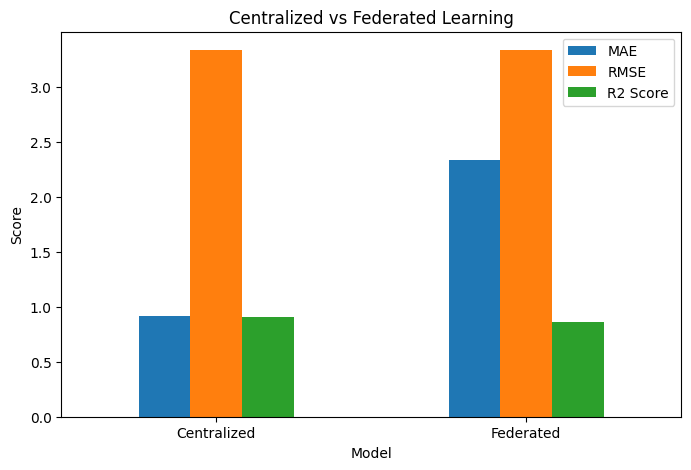

In [74]:
results_df.set_index("Model").plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Centralized vs Federated Learning")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

In [75]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
0,Application_Type,0.407171
4,Allocated_Bandwidth,0.369875
3,Required_Bandwidth,0.159258
1,Signal_Strength,0.040084
2,Latency,0.023612


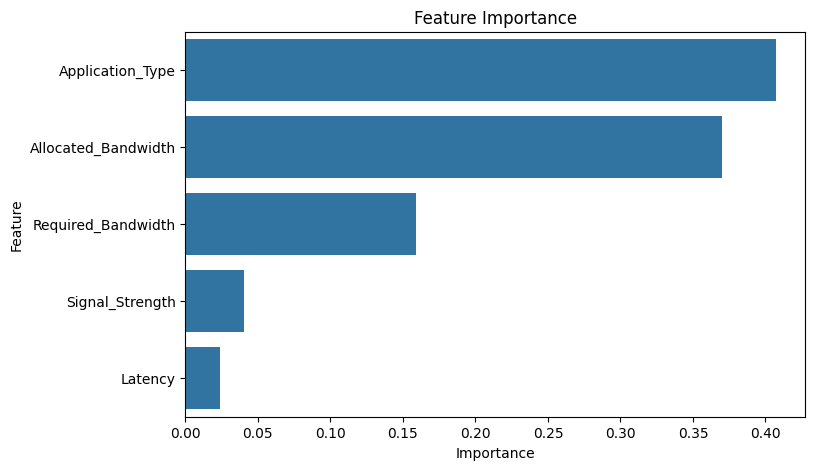

In [76]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")
plt.show()

In [77]:
import joblib

joblib.dump(model, "centralized_model.pkl")

['centralized_model.pkl']

In [78]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [79]:
importance.to_csv("feature_importance.csv", index=False)

In [80]:
prediction_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

prediction_df.to_csv("predictions.csv", index=False)

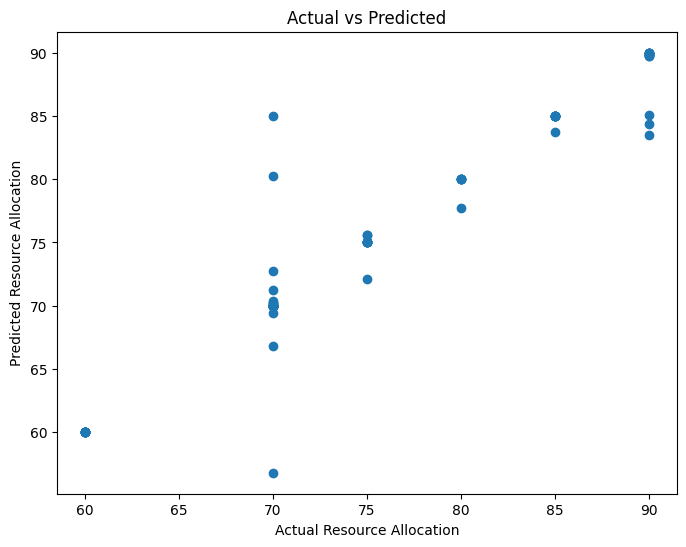

In [81]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Resource Allocation")
plt.ylabel("Predicted Resource Allocation")

plt.title("Actual vs Predicted")

plt.show()

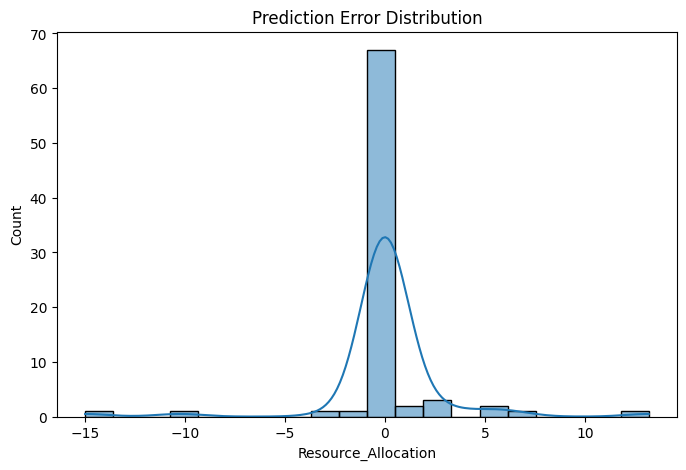

In [82]:
errors = y_test - y_pred

plt.figure(figsize=(8,5))

sns.histplot(errors, bins=20, kde=True)

plt.title("Prediction Error Distribution")

plt.show()

PROJECT SUMMARY


Federated Learning based Network Resource Allocation

Objective
Predict network resource allocation using Machine Learning and simulate Federated Learning for decentralized telecom analytics.

Technologies
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Random Forest
- Federated Learning (Simulation)

Dataset
5G Network Resource Allocation Dataset

Workflow
1. Data Collection
2. Data Cleaning
3. Exploratory Data Analysis
4. Feature Engineering
5. Model Training
6. Model Evaluation
7. Federated Learning Simulation
8. Result Comparison

In [83]:
print("========== FINAL RESULTS ==========")
print("MAE :", mae)
print("RMSE :", rmse)
print("R² Score :", r2)

========== FINAL RESULTS ==========
MAE : 2.3351249999999997
RMSE : 3.3328900746949333
R² Score : 0.8619759217661255
